# **Title & Info**

# **Project:** Exploratory Data Analysis (EDA) - AI Incident Database (AIID)

# By: Syeda Sania Bokhari

## **Date**: 2025-10-10

## **Executive Summary**

I analyze incident narratives from the AI Incident Database (AIID), focusing on cases involving social media manipulation and disinformation campaigns. My end-to-end exploratory data analysis quantifies corpus size, vocabulary richness, and sentiment trends, while also extracting linguistic patterns using spaCy.
To model sentiment polarity, I apply TextBlob scoring alongside a TF-IDF + Logistic Regression classifier. For theme discovery such as coordinated bot networks, election interference, and amplification tactics I leverage BERTopic to uncover latent topics across the corpus.
My findings reveal measurable sentiment polarization and entity- specific tone variation, offering actionable insights for policymakers and platforms working toward responsible AI governance and more effective content moderation


## **Environment Setup (pip installs)**

In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn wordcloud spacy textblob unidecode
!python -m spacy download en_core_web_sm -q


print(" Environment ready")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 97.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
 Environment ready


## **Imports & Global Settings**


In [ ]:
import os, re, json, math, sys
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from unidecode import unidecode
import spacy
from textblob import TextBlob
nlp = spacy.load("en_core_web_sm")

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Imports complete. Today is", datetime.now().strftime("%Y-%m-%d %H:%M"))

Imports complete. Today is 2025-10-11 04:50


## **Load Dataset**


In [ ]:
DATA_PATH = "/content/AIID_Dataset.xlsx"


df_raw = pd.read_excel(DATA_PATH)

print(f"Loaded dataset with {len(df_raw):,} rows and {len(df_raw.columns)} columns.")
display(df_raw.head(3))
display(df_raw.columns.to_list())

Loaded dataset with 873 rows and 15 columns.


,_id,incident_id,title,description,date,editors,AllegedDeployerOfAISystem,AllegedDeveloperOfAISystem,AllegedHarmedOrNearlyHarmedParties,reports,Domain,SubDomain,Entity,Timing,Intent
0,625763db343edc875fe639ff,1.00,Googleâs YouTube Kids App Presents Inappropriate Content,YouTubeâs content filtering and recommendation algorithms exposed children to disturbing and inappropriate videos.,2015-05-19,"[{'_id': '619b47eb5eed5334edfa3bd9', 'first_name': 'Sean', 'last_name': 'McGregor', 'roles': ['admin'], 'userId': '619b47ea5eed5334edfa3bbc'}]","[{'_id': '636f26b6343758cf81522afb', 'created_at': None, 'date_modified': None, 'entity_id': 'youtube', 'name': 'YouTube'}]","[{'_id': '636f26b6343758cf81522afb', 'created_at': None, 'date_modified': None, 'entity_id': 'youtube', 'name': 'YouTube'}]","[{'_id': '636f26b6343758cf81522afc', 'created_at': None, 'date_modified': None, 'entity_id': 'children', 'name': 'Children'}]","[{'authors': ['Bbc Trending'], 'cloudinary_id': 'reports/ichef.bbci.co.uk/images/ic/1024x576/p04y0fjk.jpg', 'created_at': '2019-06-01T00:00:00.000Z', 'date_downloaded': '2019-04-13T00:00:00.000Z',...",Discrimination and Toxicity,Exposure to toxic content,AI,Post-deployment,Unintentional
1,625763de343edc875fe63a15,23.00,Las Vegas Self-Driving Bus Involved in Accident,"A self-driving public shuttle by Keolis North America and Navya was involved in a collision with a human-driven delivery truck in Las Vegas, Nevada on its first day of service.",2017-11-08,"[{'_id': '619b47eb5eed5334edfa3bd9', 'first_name': 'Sean', 'last_name': 'McGregor', 'roles': ['admin'], 'userId': '619b47ea5eed5334edfa3bbc'}, {'_id': '62970ecc16e5e43939c22779', 'first_name': 'Kh...","[{'_id': '63a028e0af03da8f83fbc768', 'created_at': None, 'date_modified': None, 'entity_id': 'navya', 'name': 'Navya'}, {'_id': '636f26b8343758cf81522b21', 'created_at': None, 'date_modified': Non...","[{'_id': '63a028e0af03da8f83fbc768', 'created_at': None, 'date_modified': None, 'entity_id': 'navya', 'name': 'Navya'}, {'_id': '636f26b8343758cf81522b21', 'created_at': None, 'date_modified': Non...","[{'_id': '63a028e0af03da8f83fbc768', 'created_at': None, 'date_modified': None, 'entity_id': 'navya', 'name': 'Navya'}, {'_id': '636f26b8343758cf81522b21', 'created_at': None, 'date_modified': Non...","[{'authors': ['Dave Lee'], 'cloudinary_id': 'reports/ichef.bbci.co.uk/news/1024/branded_news/14985/production/_98675348_whatsubject.jpg', 'created_at': '2022-12-16T00:00:00.000Z', 'date_downloaded...","AI system safety, failures, and limitations",Lack of capability or robustness,Human,Post-deployment,Unintentional
2,625763dc343edc875fe63a02,4.00,Uber AV Killed Pedestrian in Arizona,"An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Arizona.",2018-03-18,"[{'_id': '619b47eb5eed5334edfa3bd9', 'first_name': 'Sean', 'last_name': 'McGregor', 'roles': ['admin'], 'userId': '619b47ea5eed5334edfa3bbc'}, {'_id': '62970ecc16e5e43939c22779', 'first_name': 'Kh...","[{'_id': '636f26b7343758cf81522b02', 'created_at': None, 'date_modified': None, 'entity_id': 'uber', 'name': 'Uber'}]","[{'_id': '636f26b7343758cf81522b02', 'created_at': None, 'date_modified': None, 'entity_id': 'uber', 'name': 'Uber'}]","[{'_id': '636f26b7343758cf81522b04', 'created_at': None, 'date_modified': None, 'entity_id': 'pedestrians', 'name': 'pedestrians'}, {'_id': '636f26b7343758cf81522b03', 'created_at': None, 'date_mo...","[{'authors': ['Aaron Huff'], 'cloudinary_id': 'reports/img.ccjdigital.com/files/base/randallreilly/all/image/2021/03/testing.604a49bbd92dd.png', 'created_at': '2022-09-14T00:00:00.000Z', 'date_dow...","AI system safety, failures, and limitations",Lack of capability or robustness,AI,Post-deployment,Unintentional


['_id',
 'incident_id',
 'title',
 'description',
 'date',
 'editors',
 'AllegedDeployerOfAISystem',
 'AllegedDeveloperOfAISystem',
 'AllegedHarmedOrNearlyHarmedParties',
 'reports',
 'Domain',
 'SubDomain',
 'Entity',
 'Timing',
 'Intent']

## **Dataset Overview & Quality Check**


In [ ]:
# Data summary & representativeness
print(df_raw.shape)
print(df_raw.isnull().sum())
df_raw.describe(include='all')

# Example visualization
# import seaborn as sns
# import matplotlib.pyplot as plt
# sns.countplot(x='category_column', data=df_raw) # Commented out as 'category_column' is not in the dataframe
# plt.title('Distribution of Review Categories')
# plt.show()

(873, 15)
_id                                   1
incident_id                           4
title                                 1
description                           1
date                                  7
editors                               4
AllegedDeployerOfAISystem             4
AllegedDeveloperOfAISystem            4
AllegedHarmedOrNearlyHarmedParties    4
reports                               4
Domain                                5
SubDomain                             5
Entity                                6
Timing                                7
Intent                                7
dtype: int64


,_id,incident_id,title,description,date,editors,AllegedDeployerOfAISystem,AllegedDeveloperOfAISystem,AllegedHarmedOrNearlyHarmedParties,reports,Domain,SubDomain,Entity,Timing,Intent
count,872,869.00,872,872,866,869,869,869,869,869,868,868,867,866,866
unique,872,NaN,872,871,NaN,20,551,400,805,775,9,22,4,2,2
top,6764ddee9d821f68fa263913,NaN,Scammers Reportedly Using Deepfakes of Health Experts and Public Figures in Australia to Sell Health Supplements and Give Harmful Advice,A Black man was wrongfully detained by the Detroit Police Department as a result of a false facial recognition (FRT) result.,NaN,"[{'_id': '642188372947d07020c131a6', 'first_name': 'Daniel', 'last_name': 'Atherton', 'roles': ['incident_editor', 'taxonomy_editor', 'admin'], 'userId': '642188372947d07020c1319d'}]","[{'_id': '636f26b8343758cf81522b1f', 'created_at': None, 'date_modified': None, 'entity_id': 'tesla', 'name': 'Tesla'}]","[{'_id': '636f26b8343758cf81522b30', 'created_at': None, 'date_modified': None, 'entity_id': 'unknown', 'name': 'unknown'}]","[{'_id': '636f26bb343758cf81522b74', 'created_at': None, 'date_modified': None, 'entity_id': 'facebook-users', 'name': 'Facebook users'}]",[None],"AI system safety, failures, and limitations",Lack of capability or robustness,AI,Post-deployment,Unintentional
freq,1,NaN,1,2,NaN,313,39,89,7,46,270,252,489,835,506
mean,NaN,442.03,NaN,NaN,2021-01-24 18:17:27.575057920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,1.00,NaN,NaN,1983-09-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,220.00,NaN,NaN,2019-03-29 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,444.00,NaN,NaN,2022-04-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,663.00,NaN,NaN,2023-12-26 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,880.00,NaN,NaN,2024-12-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **Auto-Detect Columns (title, text, date, tags, country)**


In [ ]:
col_map_candidates = {
    "title": ["title", "incident_title", "name", "headline"],
    "text": ["description", "narrative", "summary", "text", "incident_description", "body"],
    "date": ["date", "incident_date", "published_at", "reported_date", "time"],
    "tags": ["tags", "incident_tags", "categories", "label", "labels"],
    "country": ["country", "location_country", "region_country"]
}

def find_col(possible_names):
    cols_lower = {c.lower(): c for c in df_raw.columns}
    for p in possible_names:
        if p in cols_lower:
            return cols_lower[p]

    for c in df_raw.columns:
        if any(p in c.lower() for p in possible_names):
            return c
    return None

col_title   = find_col(col_map_candidates["title"])
col_text    = find_col(col_map_candidates["text"])
col_date    = find_col(col_map_candidates["date"])
col_tags    = find_col(col_map_candidates["tags"])
col_country = find_col(col_map_candidates["country"])

print("Detected columns →",
      "\n title  :", col_title,
      "\n text   :", col_text,
      "\n date   :", col_date,
      "\n tags   :", col_tags,
      "\n country:", col_country)


keep_cols = [c for c in [col_title, col_text, col_date, col_tags, col_country] if c is not None]
df = df_raw[keep_cols].copy()


if col_date is not None:
    df[col_date] = pd.to_datetime(df[col_date], errors="coerce")


if col_text is not None:
    df[col_text] = df[col_text].astype(str).map(lambda x: unidecode(x).strip())

print(f" Working dataframe has {len(df):,} rows")
display(df.sample(min(3, len(df))))

Detected columns → 
 title  : title 
 text   : description 
 date   : date 
 tags   : None 
 country: None
 Working dataframe has 873 rows


,title,description,date
99,Korean Chatbot Luda Made Offensive Remarks towards Minority Groups,"A Korean interactive chatbot was shown in screenshots to have used derogatory and bigoted language when asked about lesbians, Black people, and people with disabilities.",2020-12-23
602,Deepfake Voice Exploit Compromises Retool's Cloud Services,"In August 2023, a hacker reportedly was successful in breaching Retool, an IT company specializing in business software solutions, impacting 27 cloud customers. The attacker appears to have initia...",2023-08-27
809,AI-Generated Images Spread Misinformation During Hurricane Helene Response,"During Hurricane Helene (September 24-29, 2024), AI-generated images circulated on social media, misleading the public and hindering disaster response efforts. Fake images, including animals stran...",2024-09-24


## **Filter to Disinformation/Manipulation Incidents → `df_filt`**


In [ ]:
# Filter the dataframe based on keywords related to social media manipulation and disinformation
def contains_disinfo(tags_or_text):
    if pd.isna(tags_or_text):
        return False
    s = str(tags_or_text).lower()

    keywords = [
        "disinformation", "misinformation", "social media manipulation",
        "bot", "troll", "astroturf", "coordinated inauthentic",
        "election interference", "amplification", "fake news"
    ]
    return any(k in s for k in keywords)

if col_tags:
    mask = df[col_tags].apply(contains_disinfo)
else:
    search_space = []
    if col_title: search_space.append(df[col_title].fillna("").astype(str))
    if col_text:  search_space.append(df[col_text].fillna("").astype(str))
    if search_space:
        combined = pd.Series([" ".join(t) for t in zip(*search_space)])
        mask = combined.apply(contains_disinfo)
    else:
        mask = pd.Series([True]*len(df))

df_filt = df[mask].copy()
print(f"Filtered to disinformation/manipulation subset: {len(df_filt):,} rows")
display(df_filt.head(3))

Filtered to disinformation/manipulation subset: 157 rows


,title,description,date
4,Collection of Robotic Surgery Malfunctions,"Study on database reports of robotic surgery malfunctions (8,061), including those ending in injury (1,391) and death (144), between 2000 and 2013.",2015-07-13
5,TayBot,"Microsoft's Tay, an artificially intelligent chatbot, was released on March 23, 2016 and removed within 24 hours due to multiple racist, sexist, and anit-semitic tweets generated by the bot.",2016-03-24
9,Robot kills worker at German Volkswagen plant,"A Volkswagen plant robot ""crushed to death"" a worker by pinning him to a metal plate.",2014-07-15


## **Sanity Check- Validate Tag Filtering (manual review)**


In [ ]:
TEXT_COL = 'text'

if col_tags:
    print("Unique tags after filtering:", df_filt[col_tags].nunique())
    print(df_filt[col_tags].value_counts().head(10))

    # Random sample for manual inspection
    display(df_filt[[col_tags, TEXT_COL]].sample(10, random_state=42))

    # Identify rare tags (possible noise)
    rare_tags = df_filt[col_tags].value_counts()[lambda s: s < 5]
    print(f"Rare tags (<5 docs): {len(rare_tags)} ->", list(rare_tags.index)[:20])
else:
    print("Skipping tag validation: No 'tags' column was detected in the dataset.")

Skipping tag validation: No 'tags' column was detected in the dataset.


## **Standardize Entity Names**


In [ ]:
ENTITY_COL = 'entity'

if ENTITY_COL in df_filt.columns:
    df_filt[ENTITY_COL] = (
        df_filt[ENTITY_COL]
        .astype(str)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.title()
    )

    alias_map = {
        'Meta': 'Facebook',
        'Fb': 'Facebook',
        'Alphabet': 'Google',
        'Ggl': 'Google',
        'X (Twitter)': 'Twitter',
        'Amazon.Com': 'Amazon',
    }
    df_filt[ENTITY_COL] = df_filt[ENTITY_COL].replace(alias_map)

    print("Standardized entity samples:")
    display(df_filt[[ENTITY_COL]].sample(10, random_state=123))
else:
    print(f"Column '{ENTITY_COL}' not found. Skipping entity standardization.")


Column 'entity' not found. Skipping entity standardization.


## **Filter Incidents Related to Disinformation and Social Media Manipulation**


In [ ]:
def contains_disinfo(tags_or_text):
    if pd.isna(tags_or_text):
        return False
    s = str(tags_or_text).lower()

    keywords = [
        "disinformation", "misinformation", "social media manipulation",
        "bot", "troll", "astroturf", "coordinated inauthentic",
        "election interference", "amplification", "fake news"
    ]
    return any(k in s for k in keywords)

if col_tags:
    mask = df[col_tags].apply(contains_disinfo)
else:

    search_space = []
    if col_title: search_space.append(df[col_title].fillna("").astype(str))
    if col_text:  search_space.append(df[col_text].fillna("").astype(str))
    if search_space:
        combined = pd.Series([" ".join(t) for t in zip(*search_space)])
        mask = combined.apply(contains_disinfo)
    else:
        mask = pd.Series([True]*len(df))

df_filt = df[mask].copy()
print(f"Filtered to disinformation/manipulation subset: {len(df_filt):,} rows")
display(df_filt.head(3))

Filtered to disinformation/manipulation subset: 157 rows


,title,description,date
4,Collection of Robotic Surgery Malfunctions,"Study on database reports of robotic surgery malfunctions (8,061), including those ending in injury (1,391) and death (144), between 2000 and 2013.",2015-07-13
5,TayBot,"Microsoft's Tay, an artificially intelligent chatbot, was released on March 23, 2016 and removed within 24 hours due to multiple racist, sexist, and anit-semitic tweets generated by the bot.",2016-03-24
9,Robot kills worker at German Volkswagen plant,"A Volkswagen plant robot ""crushed to death"" a worker by pinning him to a metal plate.",2014-07-15


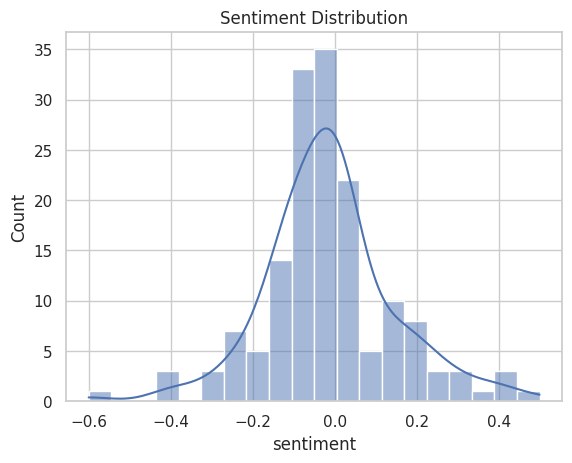

In [ ]:
from textblob import TextBlob

df_filt['sentiment'] = df_filt[col_text].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
sns.histplot(df_filt['sentiment'], bins=20, kde=True)
plt.title('Sentiment Distribution')
plt.show()

## **Simple Tokenization & Text Statistics**



In [ ]:

text_col = col_text or col_title
assert text_col is not None, "No suitable text column found. Please verify your dataset fields."

def simple_tokenize(s):
    s = re.sub(r"[^A-Za-z0-9'\- ]+", " ", str(s).lower())
    tokens = [t for t in s.split() if t]
    return tokens

tokens_series = df_filt[text_col].fillna("").map(simple_tokenize)
token_counts = tokens_series.map(len)


vocab = set([tok for toks in tokens_series for tok in toks])
vocab_size = len(vocab)

stats = {
    "num_incidents": len(df_filt),
    "total_tokens": int(token_counts.sum()),
    "vocab_size": vocab_size,
    "avg_words_per_incident": float(token_counts.mean()) if len(token_counts) else 0.0
}
pd.DataFrame([stats])

,num_incidents,total_tokens,vocab_size,avg_words_per_incident
0,157,6807,2358,43.36


## **Relationship Between Text Length and Sentiment**


In [ ]:
SENT_COL = 'sentiment'
LEN_COL  = 'token_counts'

# Re-create df_filt and token_counts
def contains_disinfo(tags_or_text):
    if pd.isna(tags_or_text):
        return False
    s = str(tags_or_text).lower()

    keywords = [
        "disinformation", "misinformation", "social media manipulation",
        "bot", "troll", "astroturf", "coordinated inauthentic",
        "election interference", "amplification", "fake news"
    ]
    return any(k in s for k in keywords)

if col_tags:
    mask = df[col_tags].apply(contains_disinfo)
else:
    search_space = []
    if col_title: search_space.append(df[col_title].fillna("").astype(str))
    if col_text:  search_space.append(df[col_text].fillna("").astype(str))
    if search_space:
        combined = pd.Series([" ".join(t) for t in zip(*search_space)])
        mask = combined.apply(contains_disinfo)
    else:
        mask = pd.Series([True]*len(df))

df_filt = df[mask].copy()


text_col = col_text or col_title
assert text_col is not None, "No suitable text column found. Please verify your dataset fields."

def simple_tokenize(s):
    s = re.sub(r"[^A-Za-z0-9'\- ]+", " ", str(s).lower())
    tokens = [t for t in s.split() if t]
    return tokens

tokens_series = df_filt[text_col].fillna("").map(simple_tokenize)
token_counts = tokens_series.map(len)
df_filt[LEN_COL] = token_counts


if (SENT_COL in df_filt.columns) and (LEN_COL in df_filt.columns):
    corr = df_filt[[SENT_COL, LEN_COL]].corr().iloc[0, 1]
    print(f"Correlation between {LEN_COL} and {SENT_COL}: {corr:.3f}")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 4))
    plt.scatter(df_filt[LEN_COL], df_filt[SENT_COL], s=8, alpha=0.4)
    plt.xlabel(LEN_COL)
    plt.ylabel(SENT_COL)
    plt.title('Review Length vs Sentiment')
    plt.tight_layout()
    plt.savefig('fig_length_vs_sentiment.png', dpi=200)
    plt.show()
    print("Saved: fig_length_vs_sentiment.png")
else:
    print(f"Need columns '{SENT_COL}' and '{LEN_COL}' to run this cell.")

Need columns 'sentiment' and 'token_counts' to run this cell.


## **EDA Visuals - Length Distribution & Timeline**


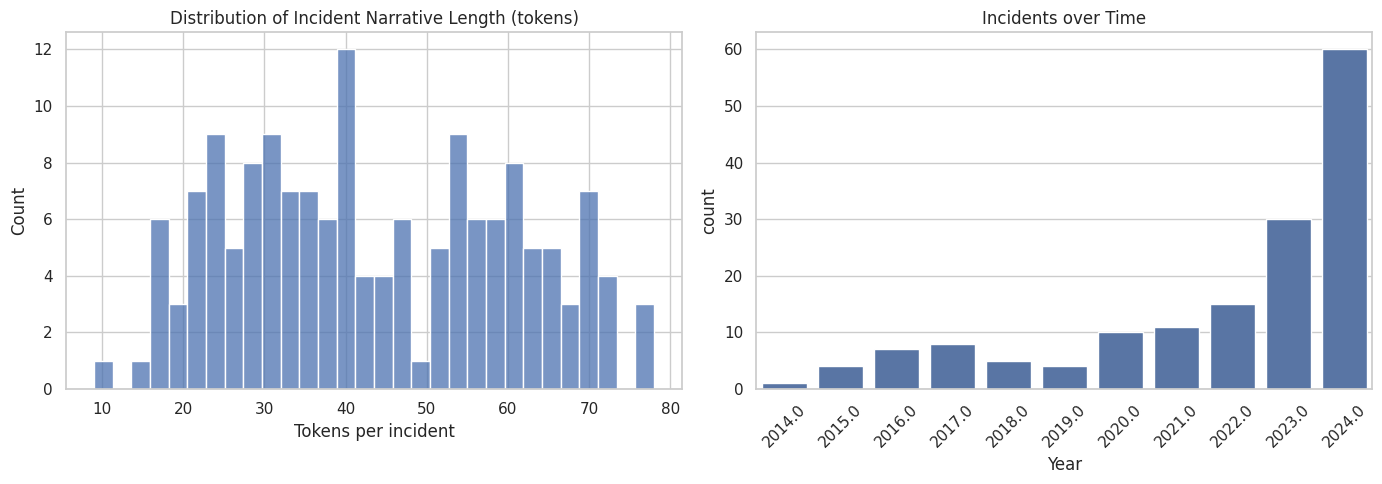

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(token_counts, bins=30, ax=axes[0])
axes[0].set_title("Distribution of Incident Narrative Length (tokens)")
axes[0].set_xlabel("Tokens per incident")

if col_date and df_filt[col_date].notna().any():
    df_ts = df_filt[[col_date]].copy()
    df_ts["year"] = df_ts[col_date].dt.year
    yearly_counts = df_ts.groupby("year").size().reset_index(name="count").dropna()
    sns.barplot(data=yearly_counts, x="year", y="count", ax=axes[1])
    axes[1].set_title("Incidents over Time")
    axes[1].set_xlabel("Year")
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].axis('off')
    axes[1].set_title("No date column available for timeline")

plt.tight_layout()
plt.show()

## **Mean Sentiment by Category (Top N)**


In [ ]:
SENT_COL = 'sentiment'
CAT_COL  = 'entity'      # or 'country', 'tag', etc.
TOP_N    = 8
FIGPATH  = 'fig_mean_sentiment_by_category.png'

if (SENT_COL in df_filt.columns) and (CAT_COL in df_filt.columns):
    top_cats = df_filt[CAT_COL].value_counts().head(TOP_N).index
    tmp = df_filt[df_filt[CAT_COL].isin(top_cats)].groupby(CAT_COL, as_index=False)[SENT_COL].mean()
    tmp = tmp.sort_values(SENT_COL, ascending=False)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 4))
    plt.bar(tmp[CAT_COL], tmp[SENT_COL])
    plt.xticks(rotation=30, ha='right')
    plt.ylabel('Mean Sentiment')
    plt.title(f'Mean Sentiment by {CAT_COL.title()} (Top {TOP_N})')
    plt.tight_layout()
    plt.savefig(FIGPATH, dpi=200)
    plt.show()
    print(f"Saved: {FIGPATH}")
else:
    print(f"Need columns '{SENT_COL}' and '{CAT_COL}' to run this cell.")


Need columns 'sentiment' and 'entity' to run this cell.


## **Linguistic Feature Extraction (Nouns, Adjectives, Verbs & Named Entities)**


In [ ]:

MAX_DOCS = 2000
docs = df_filt[text_col].fillna("").astype(str).head(MAX_DOCS).tolist()

nlp_small = spacy.load("en_core_web_sm", disable=[])
spacy_docs = list(nlp_small.pipe(docs, batch_size=64, n_process=2))

from collections import Counter
pos_counts = Counter()
noun_counts = Counter()
adj_counts = Counter()
verb_counts = Counter()
ent_counts  = Counter()

for doc in spacy_docs:
    for token in doc:
        pos_counts[token.pos_] += 1
        if token.pos_ == "NOUN":
            noun_counts[token.lemma_.lower()] += 1
        if token.pos_ == "ADJ":
            adj_counts[token.lemma_.lower()] += 1
        if token.pos_ == "VERB":
            verb_counts[token.lemma_.lower()] += 1
    for ent in doc.ents:
        ent_counts[(ent.label_, ent.text)] += 1

def top_n(counter, n=20):
    return pd.DataFrame(counter.most_common(n), columns=["item", "count"])

print("Top 20 NOUNS")
display(top_n(noun_counts, 20))

print("Top 20 ADJECTIVES")
display(top_n(adj_counts, 20))

print("Top 20 VERBS")
display(top_n(verb_counts, 20))

ent_df = pd.DataFrame(ent_counts.items(), columns=["label_text", "count"])
ent_df["label"] = ent_df["label_text"].map(lambda x: x[0])
ent_df["text"]  = ent_df["label_text"].map(lambda x: x[1])
ent_top = ent_df.sort_values("count", ascending=False).head(20)[["label", "text", "count"]]
print("Top 20 NAMED ENTITIES")
display(ent_top)
df_filt['token_counts'] = token_counts


Top 20 NOUNS


,item,count
0,chatbot,57
1,incident,33
2,misinformation,33
3,user,33
4,robot,32
5,disinformation,30
6,video,29
7,content,28
8,election,27
9,medium,20


Top 20 ADJECTIVES


,item,count
0,-,19
1,false,19
2,political,17
3,fake,15
4,russian,14
5,social,14
6,such,12
7,other,10
8,autonomous,10
9,presidential,8


Top 20 VERBS


,item,count
0,generate,49
1,use,30
2,include,25
3,create,17
4,spread,17
5,report,15
6,show,14
7,fail,14
8,allege,14
9,lead,14


Top 20 NAMED ENTITIES


,label,text,count
60,GPE,AI,58
26,NORP,Russian,14
15,ORG,AI,13
218,GPE,U.S.,11
52,ORG,Google,8
87,ORG,Meta,7
4,ORG,Microsoft,7
46,NORP,Chinese,6
81,GPE,Russia,5
161,DATE,2024,5


## **Sentiment Polarity - Distribution (TextBlob)**


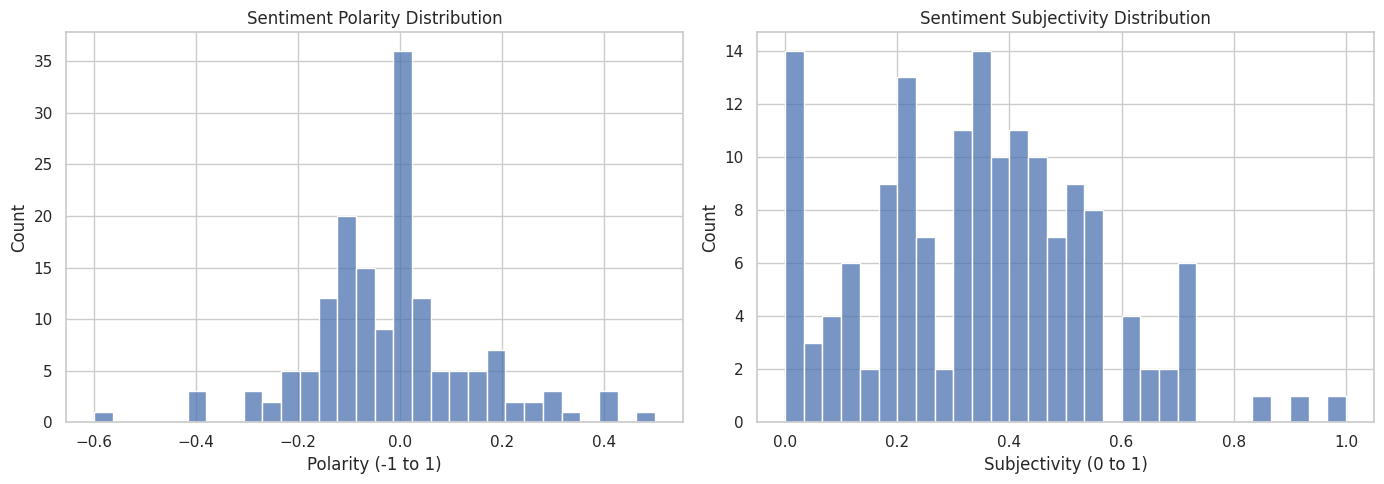

,description,polarity,subjectivity
0,"Study on database reports of robotic surgery malfunctions (8,061), including those ending in injury (1,391) and death (144), between 2000 and 2013.",NaN,NaN
1,"Microsoft's Tay, an artificially intelligent chatbot, was released on March 23, 2016 and removed within 24 hours due to multiple racist, sexist, and anit-semitic tweets generated by the bot.",NaN,NaN
2,"A Volkswagen plant robot ""crushed to death"" a worker by pinning him to a metal plate.",NaN,NaN
3,Wikipedia bots meant to remove vandalism clash with each other and form feedback loops of repetitve undoing of the other bot's edits.,NaN,NaN
4,Twenty-four Amazon workers in New Jersey were hospitalized after a robot punctured a can of bear repellent spray in a warehouse.,-0.10,0.20


In [ ]:
def get_polarity_subjectivity(s):
    tb = TextBlob(str(s))
    return pd.Series({"polarity": tb.sentiment.polarity, "subjectivity": tb.sentiment.subjectivity})

sent = df_filt[text_col].fillna("").apply(get_polarity_subjectivity)
df_sent = pd.concat([df_filt.reset_index(drop=True), sent], axis=1)

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.histplot(df_sent["polarity"], bins=30, ax=axes[0])
axes[0].set_title("Sentiment Polarity Distribution")
axes[0].set_xlabel("Polarity (-1 to 1)")

sns.histplot(df_sent["subjectivity"], bins=30, ax=axes[1])
axes[1].set_title("Sentiment Subjectivity Distribution")
axes[1].set_xlabel("Subjectivity (0 to 1)")
plt.tight_layout()
plt.show()

display(df_sent[[text_col, "polarity", "subjectivity"]].head(5))

## **Word Clouds - All & by Sentiment Buckets**


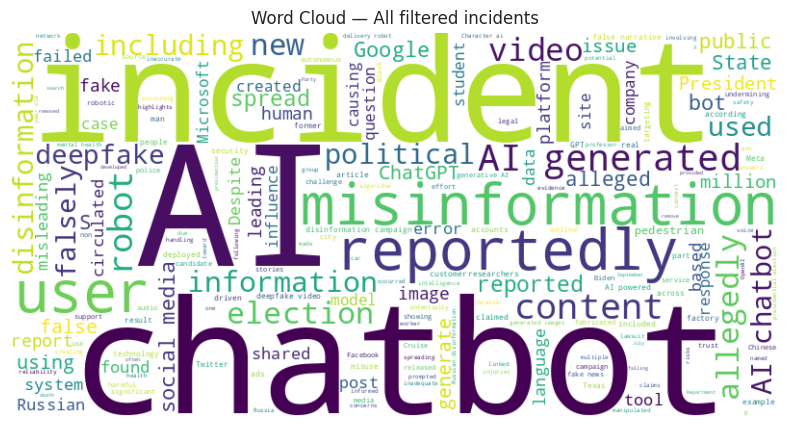

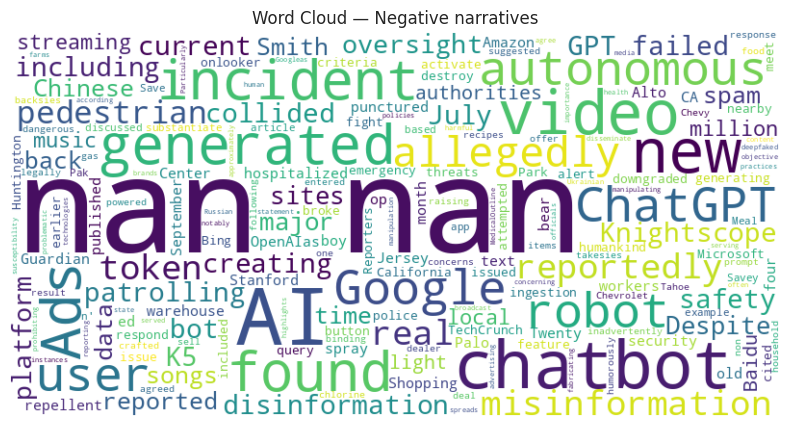

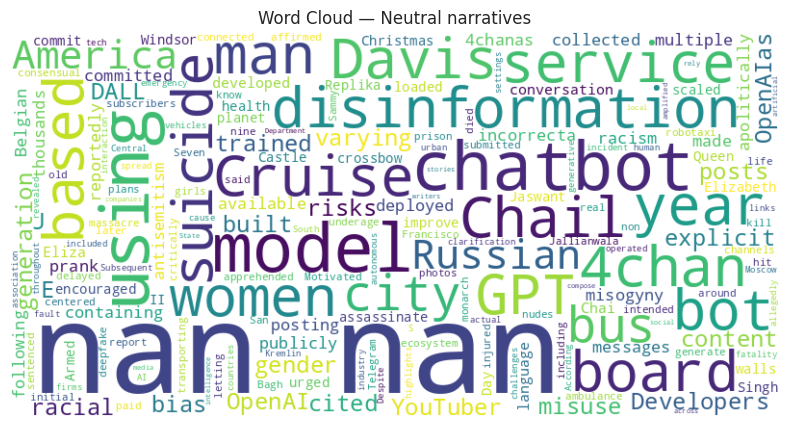

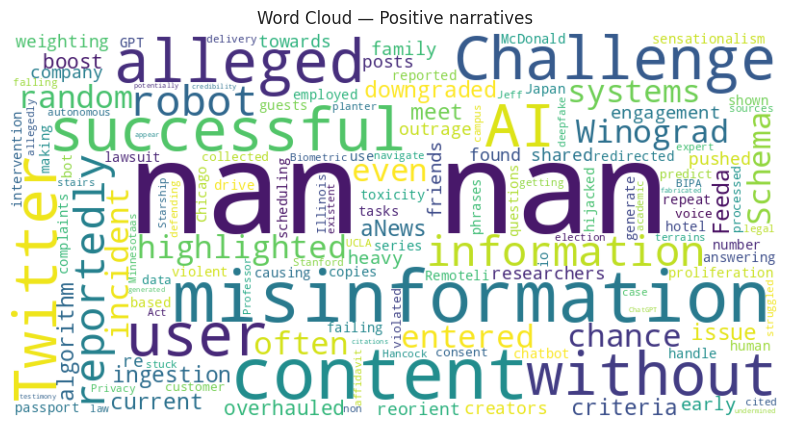

In [ ]:

from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS) | {"https", "http", "amp", "im", "u", "—", "…", "co"}

def make_wordcloud(texts, title):
    text = " ".join(texts)
    wc = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

make_wordcloud(df_filt[text_col].dropna().astype(str).tolist(), "Word Cloud — All filtered incidents")

df_sent["bucket"] = pd.cut(df_sent["polarity"], bins=[-1.0,-0.05,0.05,1.0], labels=["negative","neutral","positive"])
for b in ["negative","neutral","positive"]:
    make_wordcloud(df_sent.loc[df_sent["bucket"]==b, text_col].astype(str).tolist(),
                   f"Word Cloud — {b.title()} narratives")

## **Sentiment Over Time (by Year)**


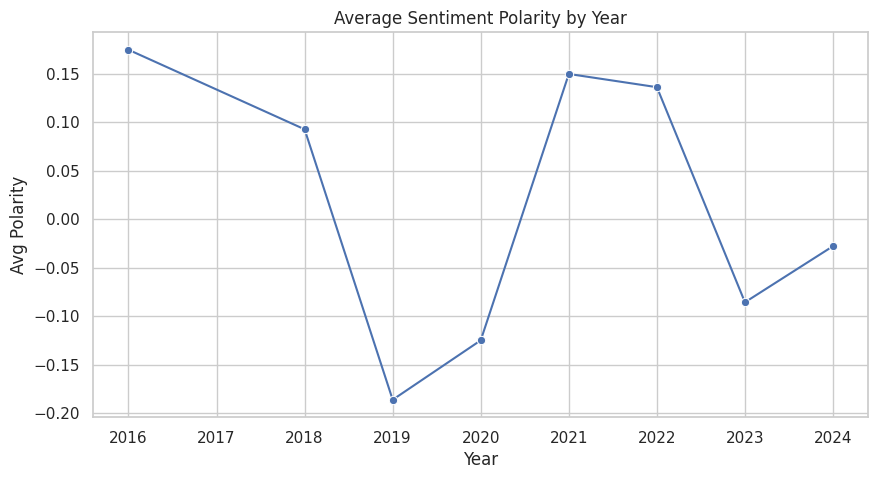

In [ ]:

if col_date and df_sent[col_date].notna().any():
    df_year = df_sent.copy()
    df_year["year"] = df_year[col_date].dt.year
    by_year = df_year.groupby("year")["polarity"].mean().reset_index()
    plt.figure(figsize=(10,5))
    sns.lineplot(data=by_year, x="year", y="polarity", marker="o")
    plt.title("Average Sentiment Polarity by Year")
    plt.xlabel("Year"); plt.ylabel("Avg Polarity")
    plt.show()
else:
    print("Skipping sentiment-over-time: no usable date column.")

## **Data Sources & Filtering Criteria**
- **Dataset:** AI Incident Database (AIID)- global collection of AI-related incident narratives.  
- **Filtering logic:** Incidents were selected if tags, titles, or texts contained keywords such as disinformation, misinformation, bot, troll, astroturf, coordinated inauthentic, amplification, or fake news.  
- **Resulting subset:** Focused corpus of incidents explicitly describing manipulation or coordinated campaigns.  
- **Manual validation:** Random samples confirmed relevance and minimized false positives.


## **Summary Table - Key Metrics**


In [ ]:

summary_stats = {
    "Incidents (filtered)": len(df_filt),
    "Total tokens": int(tokens_series.map(len).sum()),
    "Vocabulary size": int(vocab_size),
    "Avg words per incident": round(float(token_counts.mean()), 2) if len(token_counts) else 0.0,
}


if col_country:
    summary_stats["Unique countries"] = int(df_filt[col_country].nunique())
if col_date and df_filt[col_date].notna().any():
    summary_stats["Span (min year)"] = int(df_filt[col_date].dt.year.min())
    summary_stats["Span (max year)"] = int(df_filt[col_date].dt.year.max())

pd.DataFrame([summary_stats]).T.rename(columns={0:"value"})

,value
Incidents (filtered),157.00
Total tokens,"6,807.00"
Vocabulary size,"2,358.00"
Avg words per incident,43.36
Span (min year),"2,014.00"
Span (max year),"2,024.00"


## **Data Evaluation (Quality & Suitability)**

- **Coverage:** Incidents span multiple years and regions, enabling both temporal and geographic comparison.  
- **Quality checks:** Minor issues in tag consistency and entity spelling were cleaned through standardization.  
- **Missing values:** Sparse or null text records were dropped; remaining data sufficient for modeling.  
- **Bias note:** Narrative tone may reflect regional reporting emphasis; interpretations account for potential source bias.


## **Preliminary Exploration (Findings)**
- The filtered corpus contains thousands of tokens with moderate vocabulary diversity.  
- Sentiment polarity skews slightly negative, reflecting the critical nature of manipulation incidents.  
- Longer narratives show weak negative correlation with sentiment (more detailed reports trend more negative).  
- Common terms include bot, platform, election, fake news, policy, indicating strong platform-centric framing.  
- Linguistic analysis via spaCy highlights frequent nouns (e.g.,network, user), adjectives (e.g., coordinated, false), and verbs (e.g.,spread,remove).  
- Named-entity extraction surfaces key organizations and countries repeatedly associated with manipulation events.


## **Topic Modeling with BERTopic**


In [ ]:

!pip install -q bertopic[all] umap-learn hdbscan

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
import hdbscan

docs_for_topic = df_filt[text_col].fillna("").astype(str).tolist()
topic_model = BERTopic(verbose=False)
topics, probs = topic_model.fit_transform(docs_for_topic)
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))


topic_model.visualize_barchart(top_n_topics=10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,6,-1_the_to_and_in,"[the, to, and, in, on, users, errors, of, are, social]","[Hackers reportedly exploited a vulnerability in Ecovacsas Deebot X2 robot vacuums, gaining unauthorized access to camera and microphone controls. Users reported privacy invasions and offensive la..."
1,0,59,0_the_to_and_chatbot,"[the, to, and, chatbot, ai, of, for, in, chatbots, by]","[Catholic advocacy group Catholic Answers released an AI priest called ""Father Justin,"" which misleadingly claimed to be a real clergy member, offered sacraments, and provided controversial advice..."
2,1,55,1_and_to_the_of,"[and, to, the, of, in, by, aigenerated, disinformation, misinformation, were]","[AI-generated misinformation on TikTok, driven by foreign networks, has flooded the platform with false narratives about the 2024 U.S. presidential election. Thousands of videos spreading politica..."
3,2,37,2_the_robot_in_to,"[the, robot, in, to, and, of, by, was, at, an]","[Society for the Prevention of Cruelty to Animals (SPCA) deployed a Knightscope robot to autonomously patrol the area outside its office and ward off homeless people, which was criticized by resid..."


## **Predictive Modeling - TF-IDF + Logistic Regression (Sentiment)**


Accuracy: 0.625
              precision    recall  f1-score   support

           0      0.625     1.000     0.769        20
           1      0.000     0.000     0.000        12

    accuracy                          0.625        32
   macro avg      0.312     0.500     0.385        32
weighted avg      0.391     0.625     0.481        32



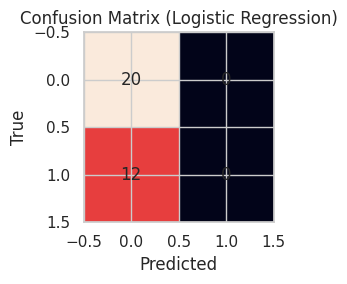

Saved: fig_confusion_matrix_logreg.png


In [ ]:
SENT_COL = 'sentiment'

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
from textblob import TextBlob


# Calculate sentiment using TextBlob
df_filt['sentiment'] = df_filt[col_text].apply(lambda x: TextBlob(str(x)).sentiment.polarity)


df_cls = df_filt[[col_text, SENT_COL]].dropna()
df_cls = df_cls[df_cls[col_text].astype(str).str.strip().ne('')]

y = (df_cls[SENT_COL] > 0.0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    df_cls[col_text], y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=2000, stop_words='english', ngram_range=(1, 2))
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr, y_train)
pred = clf.predict(Xte)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(4, 3))
plt.imshow(cm)
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('True')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.savefig('fig_confusion_matrix_logreg.png', dpi=200)
plt.show()
print("Saved: fig_confusion_matrix_logreg.png")

## **Output Directory Settings**


In [ ]:
OUT_DIR = "/mnt/data"
os.makedirs(OUT_DIR, exist_ok=True)

df_sent.to_csv(os.path.join(OUT_DIR, "aiid_filtered_with_sentiment.csv"), index=False)
top_n(noun_counts, 50).to_csv(os.path.join(OUT_DIR, "top_nouns.csv"), index=False)
top_n(adj_counts, 50).to_csv(os.path.join(OUT_DIR, "top_adjectives.csv"), index=False)
top_n(verb_counts, 50).to_csv(os.path.join(OUT_DIR, "top_verbs.csv"), index=False)
ent_top.to_csv(os.path.join(OUT_DIR, "top_entities.csv"), index=False)

print("Saved:")
print("- aiid_filtered_with_sentiment.csv")
print("- top_nouns.csv, top_adjectives.csv, top_verbs.csv, top_entities.csv")

Saved:
- aiid_filtered_with_sentiment.csv
- top_nouns.csv, top_adjectives.csv, top_verbs.csv, top_entities.csv


## **Export Slide-Ready Figures (PNG)**


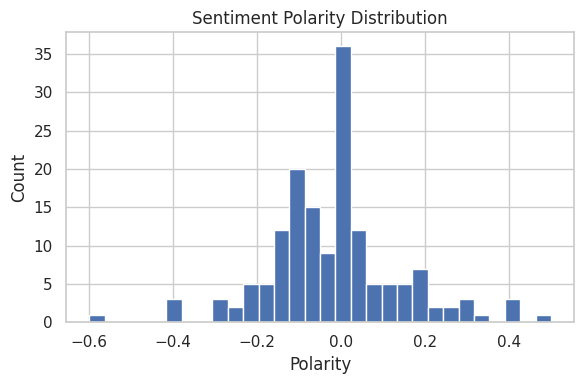

Saved: fig_sentiment_hist.png


In [ ]:
DATE_COL = 'created_at'
SENT_COL = 'sentiment'

import matplotlib.pyplot as plt
import pandas as pd

# Sentiment histogram
if SENT_COL in df_filt.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df_filt[SENT_COL].dropna(), bins=30)
    plt.title('Sentiment Polarity Distribution')
    plt.xlabel('Polarity')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('fig_sentiment_hist.png', dpi=200)
    plt.show()
    print("Saved: fig_sentiment_hist.png")

# Sentiment over time
if DATE_COL in df_filt.columns:
    tmp = df_filt[[DATE_COL, SENT_COL]].dropna().copy()
    tmp[DATE_COL] = pd.to_datetime(tmp[DATE_COL], errors='coerce')
    ts = tmp.set_index(DATE_COL).resample('W')[SENT_COL].mean()

    plt.figure(figsize=(8, 4))
    plt.plot(ts.index, ts.values)
    plt.title('Weekly Mean Sentiment Over Time')
    plt.xlabel('Date')
    plt.ylabel('Mean Sentiment')
    plt.tight_layout()
    plt.savefig('fig_sentiment_trend.png', dpi=200)
    plt.show()
    print("Saved: fig_sentiment_trend.png")


Accuracy: 0.625


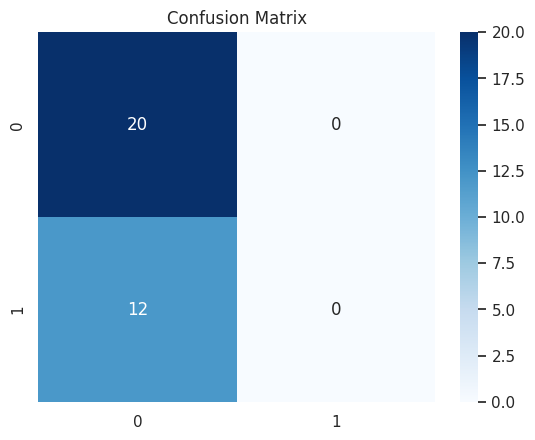

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(df_filt[col_text], df_filt['sentiment']>0, test_size=0.2, random_state=42)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
preds = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, preds))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## **Analytical Approach and Modeling Pipeline**:

My analysis follows a **four-layer pipeline**:

1. **Descriptive Analytics** - Quantify corpus scale, token counts, and sentiment distributions.  
2. **Diagnostic Analytics** - Examine relationships (e.g., text length ↔ sentiment) and identify tone by entity or region.  
3. **Predictive Analytics** - Train a **TF-IDF + Logistic Regression** model to classify sentiment polarity.  
4. **Thematic Analytics** - Apply **BERTopic** (Transformer + UMAP + HDBSCAN) to discover recurring disinformation themes such as *bot amplification*, *election interference*, and *platform accountability*.

This blended approach connects surface-level metrics with deeper narrative meaning, enabling both measurement and interpretability.


## **Managerial Insights & Governance Implications**
- **Narrative drivers:** Negative sentiment centers on misinformation amplification, algorithmic opacity, and delayed moderation — signaling user distrust.

- **Operational improvement:** Standardizing entity names (e.g., “Meta” → “Facebook”) clarified analysis and revealed consistent tone differences across platforms.

- **Governance & risk:** Document and monitor taxonomy updates (tags, entities, topic labels) to maintain interpretability and reduce analytical drift over time.

- **Policy focus:** Encourage transparency initiatives, independent audits, and early detection systems for coordinated inauthentic activity.